<a href="https://colab.research.google.com/github/stefanogiagu/AI_in_MI_2026/blob/main/AIinMI_2026_HandsOn_ViT_HAM10000.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI in Medical Image Analysis 2026
## Hands-on session on Vision Transformers

In this example we implement a Vision Transformer architecture (ViT) for image classification.

**Task:** medical images (dermatoscopic images) classification


**Dataset:** <p>
The dataset is the *HAM10000 (isic2018)* ([link](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/DBW86T)). The HAM 10000 dataset is a collection of 10015 dermatoscopic images obtained from the Medical University of Vienna, Austria, and the Cliff Rosendahl Skin Cancer Practice in Queensland Australia over the period of two years (Tschandl, Rosendahl, and Kittler 2018). Initial images from the Australia site were stored in Powerpoint files, while the Austrian images were stored as diapositives. Images were digitized with a two-fold scan, and stored as 8-bit JPEG images at 300DPI; 15x10cm. Images were then manually cropped with the lesion centered to 800x600 px at 82DPI.

The images contains representative cases of all important diagnostic categories in the realm of pigmented lesions: Actinic keratoses and intraepithelial carcinoma / Bowen's disease (akiec), basal cell carcinoma (bcc), benign keratosis-like lesions (solar lentigines / seborrheic keratoses and lichen-planus like keratoses, bkl), dermatofibroma (df), melanoma (mel), melanocytic nevi (nv) and vascular lesions (angiomas, angiokeratomas, pyogenic granulomas and hemorrhage, vasc).

In the HAM 10000 dataset the images are categorized in 7 classes, highly unbalanced (with one class representing about 70% of the whole dataset). After a partial rebalancing we endup with an effective dataset of 5275 images.


**Transformer Architecture:** <p>

We will implement the original ViT architecture: [Dosovitskiy et al., An Image Is Worth 16X16 Words: Transformers for image recognition at scale](https://arxiv.org/pdf/2010.11929.pdf), with the use of the Pre-Layer Normalization version of the Transformer blocks proposed by [Ruibin Xiong et al. in 2020](https://arxiv.org/pdf/2002.04745.pdf).

The implementation is done using pure [PyTorch](https://pytorch.org) APIs.

V2.0 - for info, latest version of the notebook, etc., contact Stefano Giagu: email: <stefano.giagu@uniroma1.it>, web: [https://www.giagu.it](https://www.giagu.it)

In [ ]:
# Download dataset (<3 GB, it takes ~3 minutes on colab)

!rm -rf data
!rm -rf ISIC2018*
!wget https://isic-challenge-data.s3.amazonaws.com/2018/ISIC2018_Task3_Training_Input.zip
!wget https://isic-challenge-data.s3.amazonaws.com/2018/ISIC2018_Task3_Training_GroundTruth.zip
!unzip -q ISIC2018_Task3_Training_Input.zip
!unzip -q ISIC2018_Task3_Training_GroundTruth.zip

--2026-05-31 13:21:03--  https://isic-challenge-data.s3.amazonaws.com/2018/ISIC2018_Task3_Training_Input.zip
Resolving isic-challenge-data.s3.amazonaws.com (isic-challenge-data.s3.amazonaws.com)... 16.15.191.13, 16.15.253.213, 52.217.128.49, ...
Connecting to isic-challenge-data.s3.amazonaws.com (isic-challenge-data.s3.amazonaws.com)|16.15.191.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2771732744 (2.6G) [application/zip]
Saving to: ‘ISIC2018_Task3_Training_Input.zip’

ISIC2018_Task3_Trai 100%[===================>]   2.58G  17.1MB/s    in 2m 43s  

2026-05-31 13:23:48 (16.2 MB/s) - ‘ISIC2018_Task3_Training_Input.zip’ saved [2771732744/2771732744]

--2026-05-31 13:23:48--  https://isic-challenge-data.s3.amazonaws.com/2018/ISIC2018_Task3_Training_GroundTruth.zip
Resolving isic-challenge-data.s3.amazonaws.com (isic-challenge-data.s3.amazonaws.com)... 52.217.205.41, 16.15.252.238, 16.15.254.3, ...
Connecting to isic-challenge-data.s3.amazonaws.com (isic-cha

In [ ]:
# organize the images in a folder structure suitable to be read with the torchvision.datasets.ImageFolder api and partially balance them
#
# first we reads the CSV file containing the labels
# the CSV file contains one row per image. The first column is the image name, while the following seven columns encode the class in one-hot format:
# example:
# image_id, akiec, bcc, bkl, df, mel, nv, vasc
# ISIC_0000001, 0, 0, 0, 0, 0, 1, 0 --> e.g. the image belong to the class nv (Melanocytic nevi)

import numpy as np
import pandas as pd

df = pd.read_csv('/content/ISIC2018_Task3_Training_GroundTruth/ISIC2018_Task3_Training_GroundTruth.csv')
labels = df.to_numpy()

import os
import shutil

# we crate 7 folders, one for each class (data/0, data/1, ..., data/6)
for i in range(7):
  os.makedirs('/content/data/'+str(i))


# to (only partially) balance classes
# we randomly undersample the classes with larger number of events
cfrac = [0.1111333 , 0.66949576, 0.05132302, 0.03265102, 0.1097354 , 0.01148278, 0.01417873]

for i in range(labels.shape[0]):
  lab = np.argmax(labels[i,1:])

  rnd = np.random.rand()
  if rnd >= cfrac[lab]:
    shutil.copyfile('/content/ISIC2018_Task3_Training_Input/'+labels[i,0]+'.jpg', '/content/data/'+str(lab)+'/'+labels[i,0]+'.jpg')

**Important note on class rebalancing**

Class imbalance is a central issue in medical AI. Accuracy alone can be misleading. A classifier trained on imbalanced data may perform well on common benign lesions but poorly on rare but clinically important classes.

There are several alternative strategies we can use:
* use weighted loss
* oversampling minority classes
* data augmentation
* focal loss
* balanced batch sampling
* reporting balanced accuracy

downsampling majoirty classes, or using weighted loss are the most popular and seafer approaches. Here we are using downsampling, you can try using instead weighted loss:

```
nn.CrossEntropyLoss(weight=class_weights)
```



In [ ]:
# imports
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import h5py
import glob

import torch
import torchvision
print(torch.__version__)
print(torchvision.__version__)

import torch.nn as nn
import torch.nn.functional as F

# for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

2.11.0+cu128
0.26.0+cu128


In [ ]:
# read data with torchvision ImageFolder

from torchvision import datasets
from torchvision.transforms import ToTensor, Resize, Compose
import PIL


data_dir = 'data'

# here we define the transformation applied to the input images
train_transforms = Compose([Resize((200,200)), #we downsampling images to 200x200 pixels to simplify task and reduce training time
                            ToTensor()         #converts PIL images to torch tensors with shape [C,H,W]=[channels=3, height=200, width=200] and normalize it in [0,1]
                           ])



# torchvision.datasets.ImageFolder function allows to read a dataset from a folder structure and associate to events labels on the base of the
# subfolders' name containing the images
# see https://pytorch.org/vision/stable/generated/torchvision.datasets.ImageFolder.html#torchvision.datasets.ImageFolder

# each element of the dataset is a pair image, label where image is a tensor [3,200,200] and label is an integer between 0 and 6
dataset = datasets.ImageFolder(data_dir, transform=train_transforms)

print(dataset)

# split dataset in training, validation and test 90:5:5 %
ev_train = int(len(dataset)*0.9)
ev_vali  = int(0.5*(len(dataset)-ev_train))
ev_test  = len(dataset) - ev_train - ev_vali
train_data, vali_data, test_data = torch.utils.data.random_split(dataset, [ev_train, ev_vali, ev_test])

print('Training set size: ', len(train_data))
print('Validation set size: ',len(vali_data))
print('Test set size: ',len(test_data))

# dataloaders
# we randomize the order of the training examples at each epoch, drop the final incomplete batch (useful when one wants all batches to have the same size),
# pin memory and use two subrpocesses for loading data in order to speedup the data transfer to the GPU

batch_size = 256
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True, drop_last=True, pin_memory=True, num_workers=2)
val_loader = torch.utils.data.DataLoader(vali_data, batch_size=batch_size, shuffle=False, drop_last=False, pin_memory=True, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False, drop_last=False, pin_memory=True, num_workers=2)

Dataset ImageFolder
    Number of datapoints: 5196
    Root location: data
    StandardTransform
Transform: Compose(
               Resize(size=(200, 200), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )
Training set size:  4676
Validation set size:  260
Test set size:  260


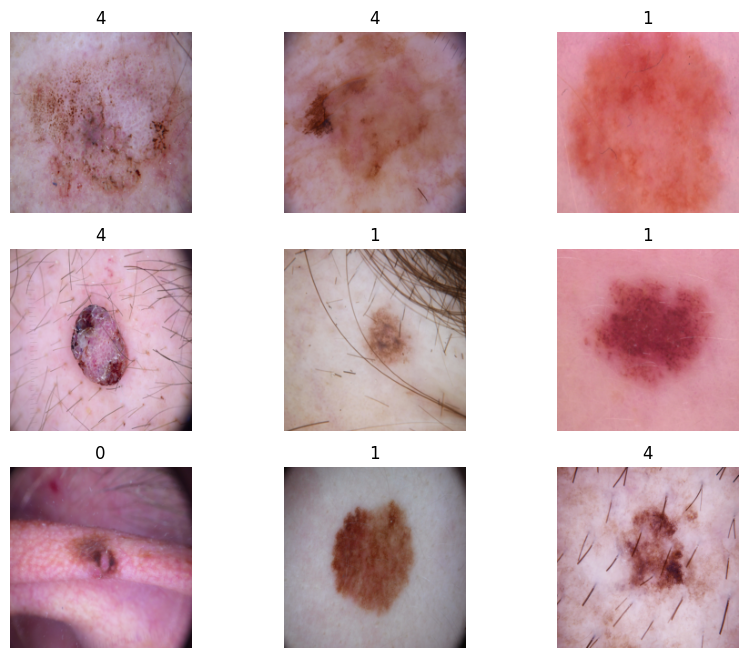

In [ ]:
# example of some of the images in the dataset

figure = plt.figure(figsize=(10, 8))
cols, rows = 3,3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_data), size=(1,)).item()
    img, label = train_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.permute(1,2,0)) #note: imshow expect image shape as (h,w,channel) while torch uses (channel,h,w)
plt.show()

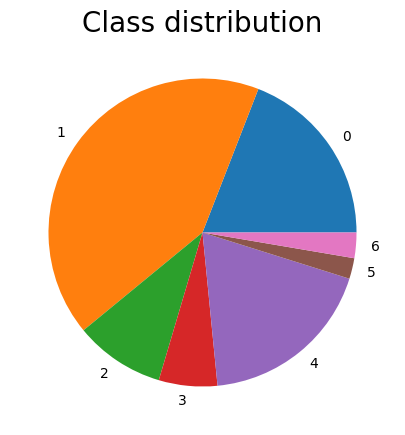

In [ ]:
# plot label frequencies in the dataset
label = train_data.dataset.targets


def piechartclasses(y):
  c = np.unique(y) #returns the ordered unique elements of an array
  arr_c = [np.mean(y==i) for i in c]


  fig = plt.figure(figsize =(8, 5))
  plt.pie(arr_c, labels = ["0", "1", "2", "3", "4", "5", "6"])
  plt.title("Class distribution",fontsize=20)
  plt.show()

piechartclasses(label)

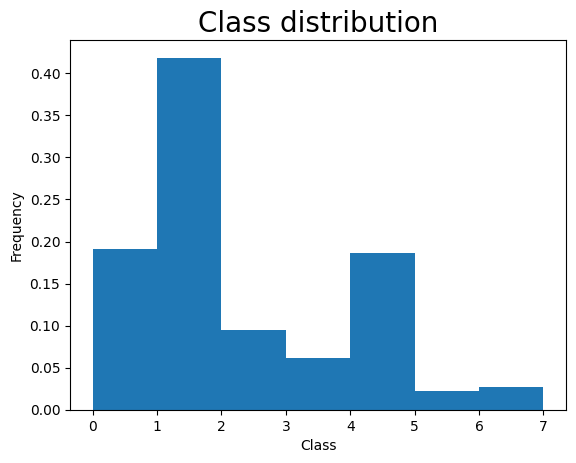

In [ ]:
_ = plt.hist(label, bins=7, range=[0,7], density=True)
plt.title("Class distribution",fontsize=20)
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# check GPU
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print('Using computation device: ',device)

Using computation device:  cuda


# ViT architecture

Transformers have been originally proposed to process sets (un-ordered lists of items) since it is a permutation-equivariant architecture, i.e., producing the same output permuted if the input is permuted.

To apply Transformers to sequences (ordered lists), we need to add a positional encoding to the input feature vectors. Hopefully the model will learn by itself how to use this additional information.

In this session we will work with images following the procedure proposed by Dosovitskiy et al.  in their paper "An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale".

Specifically, the Vision Transformer is a model for image classification that views images as sequences of smaller patches.

As a preprocessing step, we need to divide the image in a sequence of small patches.

Each of those patches is considered to be a "word"/"token" and projected to a feature space.

Then we will add a spatial encoding (additional paramenters that will encode the position of each patch in the larger image) to each patch. After this preprocessing we can apply a Transformer as usual to this sequence and start training it for our task.

Transformers can work with high resolution images and learn how to use context from very distant portion of the image.

We'll use 100 patches of 20x20 pixels, this is not an optimize value, so most probably a different choice may provide better performance ...

In [ ]:
# NOTE:
# the image size is 200x200, we divide it in patches of size 20x20, so the number of pathches will be 10x10 = 100 patches
# each patch has 20x20x3 = 1200 pixel values

# The transformer architectures of ViT is an encoder-only transformers (eg based on self-attention only: image → patches → patch embeddings → position embeddings → Transformer encoder → classifier

# A CNN sees an image as a grid. A ViT sees an image as a sequence of patches. The spatial structure is not hard-coded as strongly as in a CNN,
# the model has to learn spatial relations through positional embeddings and attention

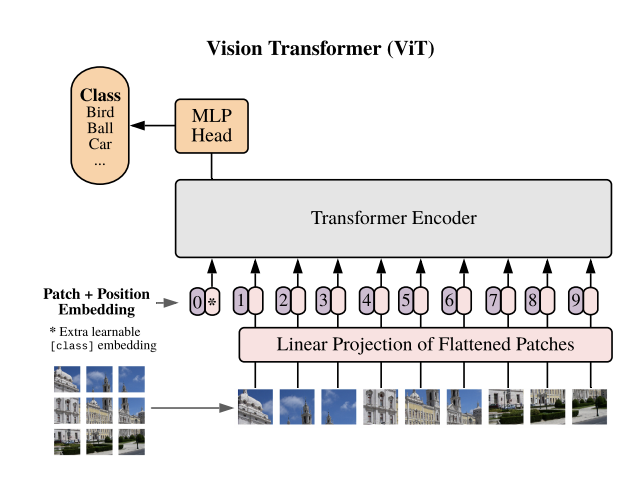

In [ ]:
from IPython.display import Image
Image('http://giagu.web.cern.ch/giagu/CERN/ViT.png', width=500)

In [ ]:
# function to divide the input batch of images in a sequence of small patches. This function is the equivalent of tokenization in NLP. In text, we split a sentence
# into words or subwords. In ViT, we split an image into patches.

# takes input [B, 3, 200, 200] and convert each of the B images in a sequence of patches with patch_size=20
# (eg 200/patch_size = 200/20 = 10 patches along height and  200/20 = 10 patches along width = 100 patches)

def img_to_patch(x, patch_size, flatten_channels=True):
    # flatten channels is more important as a parameter if we are working with multi channel images
    """
    Inputs:
        x - torch.Tensor representing the batch of images of shape [B, C, H, W]
        patch_size - Number of pixels per dimension of the patches (integer)
        flatten_channels - If True, the patches will be returned in a flattened format
                           as a feature vector instead of a image grid. This is more important when working with
                           multi channel images
    """
    B, C, H, W = x.shape
    x = x.reshape(B, C, H//patch_size, patch_size, W//patch_size, patch_size)   # [B, C, 200, 200] -> [B, C, 10, 20, 10, 20]
    x = x.permute(0, 2, 4, 1, 3, 5) # reoreder the dimensions in [B, H', W', C, p_H, p_W]: [B, C, 10, 20, 10, 20] -> [B, 10, 10, C, 20, 20] so that the two patch-grid dimensions are next to each other
    x = x.flatten(1,2)              # turns the 10x10 patches into a sequence [B, H'*W', C, p_H, p_W]: [B, 10, 10, C, 20, 20] -> [B, 100, C, 20, 20]
    if flatten_channels: # if True:
        x = x.flatten(2,4)          # [B, H'*W', C*p_H*p_W]: [B, 100, C, 20, 20] -> [B, 100, C*20*20]
    return x

In [ ]:
# visualization of image patches
NUM_IMAGES = 4
images = torch.stack([vali_data[idx][0] for idx in range(NUM_IMAGES)], dim=0) #This takes four validation images and stacks them into a mini-batch [4,3,200,200]

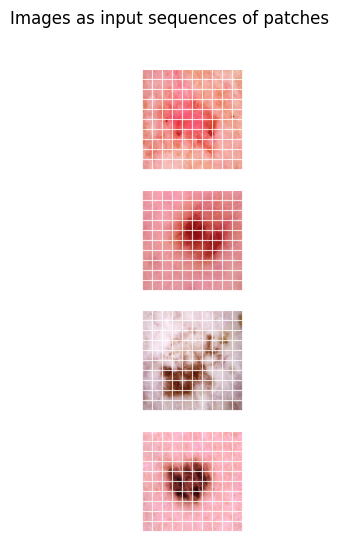

In [ ]:
img_patches = img_to_patch(images, patch_size=20, flatten_channels=False) #[4, 100, 3, 20, 20]

fig, ax = plt.subplots(images.shape[0], 1, figsize=(18,6))
fig.suptitle("Images as input sequences of patches")
for i in range(images.shape[0]):
    img_grid = torchvision.utils.make_grid(img_patches[i], nrow=10, normalize=True, pad_value=1) #display the 100 patches as a 10 by 10 grid.
    img_grid = img_grid.permute(1, 2, 0)
    ax[i].imshow(img_grid)
    ax[i].axis('off')
plt.show()
plt.close()

compared to the original images, it is much harder to recognize the objects from each single patch. Still, this is the input we provide to the Transformer for classifying the images. The model has to learn itself how it has to combine the patches to recognize the objects. The inductive bias in CNNs that an image is a grid of pixels, is lost in this input format.

After we have looked at the preprocessing, we can now start building the Transformer model.

**NOTE:** we implement a Vision Transformer from scratch in PyTorch, rather than using a pretrained model (which is the standard way to use it). This is pedagogically motivated as you can see explicitly how images are converted into token sequences, how self-attention is used, and how the final classifier is built.

We use the Pre-Layer Normalization version of the Transformer blocks proposed by Ruibin Xiong et al. in 2020. The idea is to apply Layer Normalization not in between residual blocks, but instead as a first layer in the residual blocks. This reorganization of the layers supports better gradient flow and removes the necessity of a warm-up stage.

In [ ]:
class AttentionBlock(nn.Module):
    #  Implements the standard attention (multi-head attention + MLP) block for
    #  a tranformer encoder architecture

    #  structure:
    #   MHA: pre layer normalization (see Ruibin Xiong et al. (2020)) + multi-head attention (pytorch implementation) + layer normalization
    #   MLP: dense + gelu + droput + dense + dropout

    #  arguments:
    #   embed_dim  - Dimensionality of input and attention feature vectors (we'll use 64)
    #   hidden_dim - Dimensionality of hidden layer in feed-forward network
    #                (usually 2-4x larger than embed_dim, we'll use 128)
    #   num_heads  - Number of heads to use in the Multi-Head Attention block. (we'll use 8, thi smeans that each attention head will have dimension embed_dim / 8 = 64/8 = 8)
    #   dropout    - Amount of dropout to apply in the feed-forward network

    #    ^
    #    |_____    NOR2(x) + NOR2(MHA(NOR1(x))) + MLP(NOR2(MHA(NOR1(x)))): output (L,B,embde_dim)
    #    |     ^
    #  -----   |
    # | MLP |  |
    #  -----   |
    #    |_____|
    #    |
    #  -----
    # | NOR |
    #  -----
    #    |_____    x + MHA(NOR1(x))
    #    |     ^
    #  -----   |
    # | MHA |  |
    #  -----   |
    #    |     |
    #  -----   |
    # | NOR |  |
    #  -----   |
    #    |_____|
    #    |        x

    def __init__(self, embed_dim, hidden_dim, num_heads, dropout=0.0):
        super(AttentionBlock, self).__init__()

        self.layer_norm_1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads) #this pytorch function implements a full MH-Attention block (see https://pytorch.org/docs/stable/generated/torch.nn.MultiheadAttention.html)
        self.layer_norm_2 = nn.LayerNorm(embed_dim)

        self.mlp = nn.Sequential( #this is the MLP mixer of the transformer block that acts indpendently and in parallel to each token (64 -> 128 -> 64)
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(), #GELU is commonly used in transformers and is a smoother version of ReLU.
            nn.Dropout(dropout), #used for regularization
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x): #x: [L,B,D]=[sequence_length, batch_size, embedding_dimension]. In our case L=101: 100 patches + 1 CLS token, D=64
        inp_x = self.layer_norm_1(x)
        x = x + self.attn(inp_x, inp_x, inp_x)[0] #nn.MultiheadAttention expects input shapes 3x[sequence_length, batch_size, embedding_dimension] not [batch_size, sequence_length, embedding_dimension]
        x = self.layer_norm_2(x)
        x = x + self.mlp(x) #Residual connections allow the network to learn corrections to the identity map. They improve gradient flow and make deep networks easier to train
        return x

Now we have all modules ready to build our own Vision Transformer. Besides the Transformer encoder, we need the following modules:

- A linear projection layer that maps the input patches to a feature vector of larger size. It is implemented by a simple linear layer that takes each patch independently as input.

- A classification token that is added to the input sequence. We will use the output feature vector of the classification token (CLS token in short) for determining the classification prediction.

- Learnable positional encodings that are added to the tokens before being processed by the Transformer. Those are needed to learn position-dependent information, and convert the set to a sequence. Since we usually work with a fixed resolution, we can learn the positional encodings instead of having the pattern of sine and cosine functions [Here you can find a good explanation of positional encodings for NLP sequences with varing length](https://kazemnejad.com/blog/transformer_architecture_positional_encoding/).

- An MLP head that takes the output feature vector of the CLS token, and maps it to a classification prediction. This is usually implemented by a small feed-forward network or even a single linear layer.


Vision Transformer Architecture:


In [ ]:
class VisionTransformer(nn.Module):
    #  Classifier based on a ViT  architecture implementation
    #  arguments:
    #   embed_dim  - Dimensionality of embedding in input fetaure vector to the Transformer
    #   hidden_dim - Dimensionality of hidden layer in feed-forward network
    #   num_channels - Number of channels of the input (3 for RGB)
    #   num_heads  - Number of heads to use in the Multi-Head Attention block
    #   num_layers - Number of layers to use in the Transformer
    #   patch_size - Number of pixels that the patches have per dimension
    #   num_patches - Maximum number of patches an image can have
    #   num_classes- Number of categories for the classification task
    #   dropout    - Amount of dropout to apply in the feed-forward network and in the input

    def __init__(self, embed_dim, hidden_dim, num_channels, num_heads, num_layers, patch_size, num_patches, num_classes, dropout=0.0):
        super(VisionTransformer, self).__init__()

        self.patch_size = patch_size

        # input layer (a dense layer projecting the input in a embed_dim embedding space) 3x20x20=1200 -> 64 (is the equivalent of word embedding in NLPs)
        self.input_layer = nn.Linear(num_channels*(patch_size**2), embed_dim)

        # Transformer encoder: stack of num_layers Attention Blocks (embed_dim -> embed_dim) we'll use 4 layers
        self.transformer = nn.Sequential(*[AttentionBlock(embed_dim, hidden_dim, num_heads, dropout=dropout) for _ in range(num_layers)])

        # MLP Classifier (embed_dim -> num_classes) it maps the CLS token to the output class logits (54 -> 7), then the crossentropyloss will maps logits in probabilities via softmax
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

        self.dropout = nn.Dropout(dropout)


        #parameters / embedding

        # The CLS token is a learnable vector. It is added at the beginning of the patch sequence, so that for each image, the input sequence becomes:
        # [CLS], patch_1, patch_2, ..., patch_100
        # After the Transformer has processed the sequence, the output representation corresponding to the CLS token is used as a summary of the entire image.
        # The CLS token is a learnable “collector” token. Through attention, it can gather information from all image patches.

        self.cls_token = nn.Parameter(torch.randn(1,1,embed_dim))

        # the positional embedding has shape [1,101,64] (as  there are 100 pathces + the CLS token)
        # Transformers are permutation-equivariant. Without positional information, self-attention alone does not know the order or position of tokens and the model would not know whether
        # a patch came from the top-left or bottom-right of the image. So positional embeddings are added to the token embeddings to inject spatial information into the model

        self.pos_embedding = nn.Parameter(torch.randn(1,1+num_patches,embed_dim))# this is our positional  embedding. It is initialized as a random number but it is learnable so it will be optimized during training.


    def forward(self, x):
        # Preprocess input
        x = img_to_patch(x, self.patch_size)
        B, T, _ = x.shape #[B,100,1200]
        x = self.input_layer(x) #[B,100,64]

        # Add CLS token and positional encoding


        cls_token = self.cls_token.repeat(B, 1, 1)
        x = torch.cat([cls_token, x], dim=1) #[B,101,64]
        x = x + self.pos_embedding[:,:T+1] #The positional embedding is added token by token preserving thr shape: [B,101,64]. (same shape but now each token has also positional information)

        # Apply Transforrmer
        x = self.dropout(x)
        x = x.transpose(0, 1) #[batch_size, sequence_length, embedding_dimension] -> [sequence_length, batch_size, embedding_dimension] as required by pytorch MHAttention ..
        x = self.transformer(x)

        # Perform classification prediction
        cls = x[0]
        out = self.mlp_head(cls)
        return out

In [ ]:
# instantiation of a new model

# NOTE: embed_dim MUST be an integer multiple of num_heads
model_kwargs={
              'embed_dim': 64,
              'hidden_dim': 128,
              'num_heads': 8,
              'num_layers': 4,
              'patch_size': 20,
              'num_channels': 3,
              'num_patches': 100,
              'num_classes': 7,
              'dropout': 0.30
             }

model = VisionTransformer(**model_kwargs)

In [ ]:
# print the model structure

print(model)

from torchsummary import summary
if torch.cuda.is_available():
  summary(model.cuda(), input_size=(3,200,200))
else:
  summary(model, input_size=(3,200,200))

VisionTransformer(
  (input_layer): Linear(in_features=1200, out_features=64, bias=True)
  (transformer): Sequential(
    (0): AttentionBlock(
      (layer_norm_1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
      )
      (layer_norm_2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=64, out_features=128, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.3, inplace=False)
        (3): Linear(in_features=128, out_features=64, bias=True)
        (4): Dropout(p=0.3, inplace=False)
      )
    )
    (1): AttentionBlock(
      (layer_norm_1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
      )
      (layer_norm_2): LayerNorm((64,),

In [ ]:
# test the model on one batch to check everything is ok before training it

model.to(device) #move the model on device (cpu/gpu)

xb,yb=next(iter(train_loader)) #take a mini batch from the training dataloader
xb=xb.type(torch.float).to(device) #move torch tensors to device (cpu or GPU)
yb=yb.type(torch.long).to(device)
print(xb.shape)
print(yb.shape)

out=model(xb) #apply the model on the input batch
print(out.shape)

torch.Size([256, 3, 200, 200])
torch.Size([256])
torch.Size([256, 7])


## Training Procedure

We are now ready to complete the model by defining the loss function, the accuracy metric to monitor the training of the classifier, and the optmizer + learning rate scheduler.

Write two simple procedures to train and test the model on the training and test dataset, respectively.

If you are not new to PyTorch, this scheme should appear familiar to you. Otherwise, the PyTorch web site provides [a good introduction on how to train a neural network in PyTorch](https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html#define-a-loss-function-and-optimizer).

In [ ]:
#install torchmetrics: collection of useful PyTorch metrics implementations and an easy-to-use API to create custom metrics]
%pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 56.7 MB/s eta 0:00:00


In [ ]:
#loss
loss_func = nn.CrossEntropyLoss() #cross entropy loss

# metrics (accuracy)
import torchmetrics
from torchmetrics.classification import Accuracy

metric_func = Accuracy(task="multiclass", num_classes=7)
metric_func = metric_func.to(device) #NOTE: torchmetrics functions, differently from pytorch native functions) need to be moved to the computing device

# optimizer: we'll use AdamW eg Adam with a better weight decay (eg L2 regularisation) that provides better generalisation performance
from torch import optim
#opt = optim.Adam(model.parameters(), lr=1e-3)
opt = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.0001) #AdamW is a variant of Adam with decoupled weight decay (acts as regularization (L2) by penalizing large weights)
# AdamW is widely used for Transformer architectures as it usually behaves better than classical Adam when weight decay is important.

# scheduler for step decay lr schedule
#lr_scheduler = optim.lr_scheduler.MultiStepLR(opt, milestones=[20,30,35], gamma=0.2)

In [ ]:
# in pytorch you are responsible of writing the training loop, this can be done by implementig specific
# python functions for the training and validation steps, or just, like in this example, by using a simple plain
# python loop

#training loop

epochs = 100 #number of epochs

import time

best_valid_loss=float('inf') #initialize checkpoint counter

# dfine python lists to save loss and metric history
hist_loss = []
hist_metric = []
hist_vloss = []
hist_vmetric = []

#loop over epochs
for epoch in range(epochs):
    t0 = time.time()

    #training step
    model.train()

    train_loss = 0.0
    metric_func.reset()
    counter = 0
    for xb, yb in train_loader: #takes a batch from the train dataloader
        counter += 1
        xb=xb.type(torch.float).to(device) #move torch tensors to device (cpu or GPU)
        yb=yb.type(torch.long).to(device)

        pred = model(xb) #get prediction for batch
        loss = loss_func(pred, yb) #compute loss
        #print(pred.shape)
        #print(yb.shape)
        metric_func.update(pred, yb) #compute accuracy

        train_loss += loss.item() #update total loss

        # backpropagation
        loss.backward()
        # update weights
        opt.step()
        # set to zero gradients for the next step
        opt.zero_grad()

    # normalize loss and metric by number of batches
    train_loss = train_loss/(counter)
    train_metric = metric_func.compute().item()

    # update history
    hist_loss.append(train_loss)
    hist_metric.append(train_metric)

    # evaluation step (same as training but w/o backpropagation)

    model.eval()

    vali_loss = 0.0
    metric_func.reset()
    counter = 0
    with torch.no_grad():
      for xb, yb in val_loader:
        counter += 1
        xb=xb.type(torch.float).to(device)
        yb=yb.type(torch.long).to(device)
        pred = model(xb)
        vloss = loss_func(pred, yb)
        metric_func.update(pred, yb) #compute accuracy

        vali_loss += vloss.item()


    vali_loss = vali_loss/(counter)
    vali_metric = metric_func.compute().item()

    hist_vloss.append(vali_loss)
    hist_vmetric.append(vali_metric)

    #save best model
    if vali_loss < best_valid_loss:
      best_valid_loss = vali_loss
      print(f"\nBest validation loss: {best_valid_loss}")
      print(f"\nSaving best model for epoch: {epoch+1}\n")
      torch.save(model.state_dict(), 'best_model_w.pth')


    elapsed_time = time.time()-t0
    #current_lr = lr_scheduler.get_last_lr()[0]
    #print("epoch: %d, time(s): %.2f, train loss: %.6f, train metric: %.6f, vali loss: %.6f, vali metric: %.6f,  lr : %1.2e" % (epoch+1, elapsed_time, train_loss, train_metric, vali_loss, vali_metric,current_lr))
    print("epoch: %d, time(s): %.2f, train loss: %.6f, train metric: %.6f, vali loss: %.6f, vali metric: %.6f" % (epoch+1, elapsed_time, train_loss, train_metric, vali_loss, vali_metric))

    # update learning rate schedule
    #lr_scheduler.step()


Best validation loss: 1.287282109260559

Saving best model for epoch: 1

epoch: 1, time(s): 20.94, train loss: 1.627140, train metric: 0.397786, vali loss: 1.287282, vali metric: 0.434615

Best validation loss: 1.250004768371582

Saving best model for epoch: 2

epoch: 2, time(s): 20.93, train loss: 1.580427, train metric: 0.418620, vali loss: 1.250005, vali metric: 0.434615

Best validation loss: 1.1504093408584595

Saving best model for epoch: 3

epoch: 3, time(s): 21.16, train loss: 1.562941, train metric: 0.419054, vali loss: 1.150409, vali metric: 0.430769

Best validation loss: 1.0476875305175781

Saving best model for epoch: 4

epoch: 4, time(s): 21.23, train loss: 1.498389, train metric: 0.410807, vali loss: 1.047688, vali metric: 0.476923

Best validation loss: 0.9118136167526245

Saving best model for epoch: 5

epoch: 5, time(s): 21.26, train loss: 1.466168, train metric: 0.411675, vali loss: 0.911814, vali metric: 0.503846

Best validation loss: 0.8919717520475388

Saving be

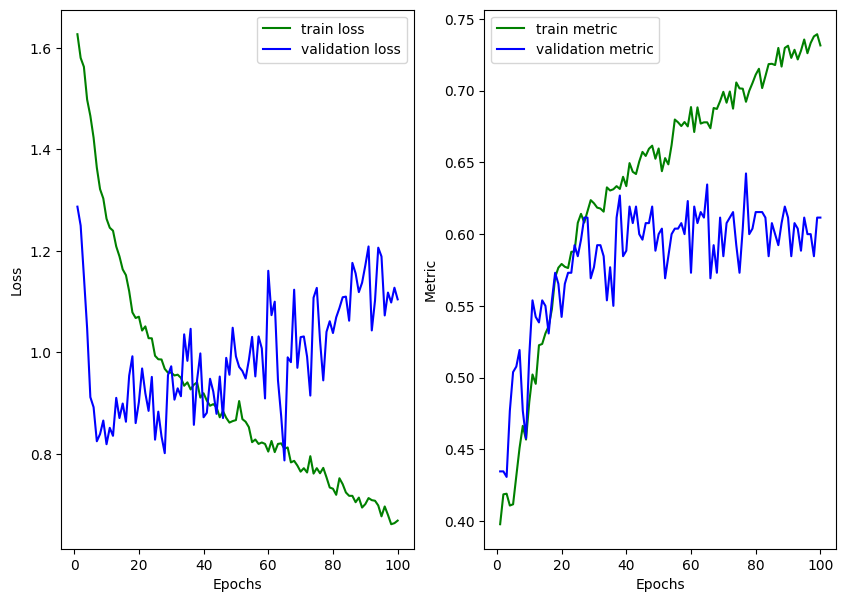

In [ ]:
# plot training results (loss and accuracy vs epoch)

plt.figure(figsize=(10, 7))
plt.subplot(1,2,1)
plt.plot(range(1,len(hist_loss)+1), hist_loss, color='green', linestyle='-', label='train loss')
plt.plot(range(1,len(hist_vloss)+1), hist_vloss, color='blue', linestyle='-', label='validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1,2,2)
plt.plot(range(1,len(hist_metric)+1), hist_metric,  color='green', linestyle='-', label='train metric')
plt.plot(range(1,len(hist_vmetric)+1),hist_vmetric, color='blue', linestyle='-', label='validation metric')
plt.xlabel('Epochs')
plt.ylabel('Metric')
plt.legend()

In [ ]:
# load the best model weights
checkpoint = torch.load('./best_model_w.pth')
model = VisionTransformer(**model_kwargs)
model.load_state_dict(checkpoint)
model.eval()

VisionTransformer(
  (input_layer): Linear(in_features=1200, out_features=64, bias=True)
  (transformer): Sequential(
    (0): AttentionBlock(
      (layer_norm_1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
      )
      (layer_norm_2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=64, out_features=128, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.3, inplace=False)
        (3): Linear(in_features=128, out_features=64, bias=True)
        (4): Dropout(p=0.3, inplace=False)
      )
    )
    (1): AttentionBlock(
      (layer_norm_1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
      )
      (layer_norm_2): LayerNorm((64,),

In [ ]:
# inference on test set
pred_prob = torch.empty(size=(0,7), device=device) #note the device parameter, this allows to create the torch tensors directly in the needed device
pred_val = torch.empty(size=(0,), device=device)
ground_truth = torch.empty(size=(0,), device=device)

model.to(device)

test_loss = 0.0
test_metric = 0.0

counter=0
with torch.no_grad():
  for xb, yb in test_loader:
    counter += 1
    xb=xb.type(torch.float).to(device)
    yb=yb.type(torch.long).to(device)
    res = model(xb)
    pre = torch.softmax(res, dim=1)
    val = pre.argmax(dim=1)
    pred_prob = torch.cat((pred_prob, pre), dim=0)
    pred_val = torch.cat((pred_val, val), dim=0)
    ground_truth = torch.cat((ground_truth, yb), dim=0)
    vloss = loss_func(res, yb)
    vmetric = metric_func(res, yb)
    test_loss += vloss.item()
    test_metric += vmetric.item()

test_loss = test_loss/(counter)
test_metric = test_metric/(counter)

predict_val = pred_val.cpu().data.numpy()
predict_prob = pred_prob.cpu().data.numpy()
true_val = ground_truth.cpu().data.numpy()

print('test loss: ', test_loss)
print('test average accuracy: ', test_metric)

test loss:  1.1809102296829224
test average accuracy:  0.66796875


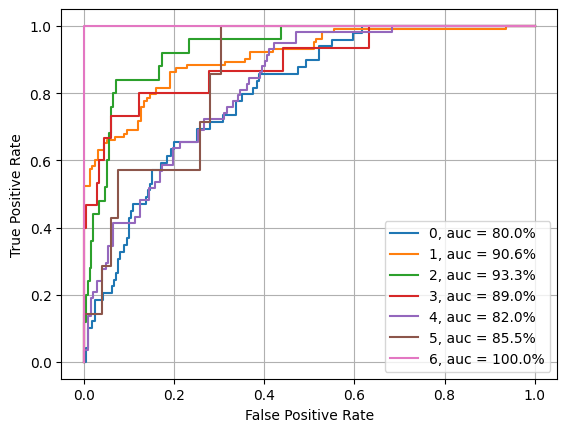

In [ ]:
from sklearn.metrics import roc_curve, auc

# print ROC curves
fpr = {}
tpr = {}
auc1 = {}
plt.figure()
for i, label in enumerate(range(7)): #7 classes
        fpr[label], tpr[label], threshold = roc_curve((true_val==i), predict_prob[:,i]) #treats class i as positive and all other classes as negative
        auc1[label] = auc(fpr[label], tpr[label])
        plt.plot(fpr[label],tpr[label],label='%s, auc = %.1f%%'%(label,auc1[label]*100.))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.legend(loc='lower right')
plt.show()

In [ ]:
#function to print a formatted confusion matrix
def print_cm(cm, labels, hide_zeroes=False, hide_diagonal=False, hide_threshold=None):
    """pretty print for confusion matrixes"""
    columnwidth = max([len(x) for x in labels] + [5])  # 5 is value length
    empty_cell = " " * columnwidth
    # Print header
    print("    " + empty_cell, end=" ")
    for label in labels:
        print("%{0}s".format(columnwidth) % label, end=" ")
    print()

    # Print rows
    for i, label1 in enumerate(labels):
        print("    %{0}s".format(columnwidth) % label1, end=" ")
        for j in range(len(labels)):
            cell = "%{0}.2f".format(columnwidth) % cm[i, j]
            if hide_zeroes:
                cell = cell if float(cm[i, j]) != 0 else empty_cell
            if hide_diagonal:
                cell = cell if i != j else empty_cell
            if hide_threshold:
                cell = cell if cm[i, j] > hide_threshold else empty_cell
            print(cell, end=" ")
        print()

In [ ]:
# confusion matrix

mylabels = [str(i) for i in list(range(7))]

from sklearn.metrics import confusion_matrix
c_mat = confusion_matrix(true_val, predict_val, normalize='true')
print("Confusion Matrix:")
print("")
print_cm(c_mat,mylabels)

Confusion Matrix:

              0     1     2     3     4     5     6 
        0  0.63  0.20  0.00  0.00  0.14  0.00  0.02 
        1  0.12  0.82  0.00  0.00  0.07  0.00  0.00 
        2  0.32  0.20  0.20  0.00  0.28  0.00  0.00 
        3  0.27  0.00  0.07  0.20  0.47  0.00  0.00 
        4  0.31  0.22  0.00  0.00  0.45  0.00  0.02 
        5  0.29  0.43  0.14  0.00  0.00  0.14  0.00 
        6  0.00  0.00  0.00  0.00  0.00  0.00  1.00 


**NOTE:** much better perfromance can be obtained by:
1. use larger size images (eg reduce the downsizing)
2. pretrain the visual transformer on a larger dataset (imagenet), or use an already pretrained ViT,  then fine tune to the HAM10000 dataset
3. tune the model hyperparameters (batch size, learning rate and weight decays, number of patches/patch size, dimension, etc)
4. try to use weighted loss for class imbalance
